# Market Data Exploration

## Objective

The purpose of this notebook is to explore historical market data before developing systematic trading strategies.

This analysis focuses on:

- Historical price behaviour
- Daily returns
- Volatility
- Distribution of returns
- Data quality

The results of this notebook will be used in the following research notebooks for strategy development and portfolio construction.

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from app.data_loader import load_market_data

In [4]:
df = load_market_data("AAPL")

df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000
2015-01-06,23.513268,23.772165,23.152579,23.575226,263188400
2015-01-07,23.842976,23.942551,23.610630,23.721271,160423600
2015-01-08,24.759083,24.816616,24.053197,24.170477,237458000


## Dataset Overview

The dataset contains historical OHLCV market data downloaded from Yahoo Finance.

The variables include:

- Open
- High
- Low
- Close
- Volume

These variables will later be transformed into technical indicators.

In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2902 entries, 2015-01-02 to 2026-07-20
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2902 non-null   float64
 1   High    2902 non-null   float64
 2   Low     2902 non-null   float64
 3   Open    2902 non-null   float64
 4   Volume  2902 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 136.0 KB


In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
count,2902.000000,2902.000000,2902.000000,2902.000000,2.902000e+03
mean,114.147243,115.293209,112.897008,114.043520,1.085502e+08
std,81.102388,81.909827,80.221894,81.013786,6.785353e+07
min,20.565868,20.868641,20.367814,20.488467,1.791060e+07
25%,37.389153,37.735981,36.987140,37.367932,6.089400e+07
50%,112.711052,114.270543,111.149280,112.827337,9.134325e+07
75%,174.156612,175.756522,172.041611,174.057097,1.345435e+08
max,333.739990,334.989990,329.000000,333.024994,6.488252e+08


## Historical Price Behaviour

The following figure illustrates the historical evolution of Apple's adjusted closing price.

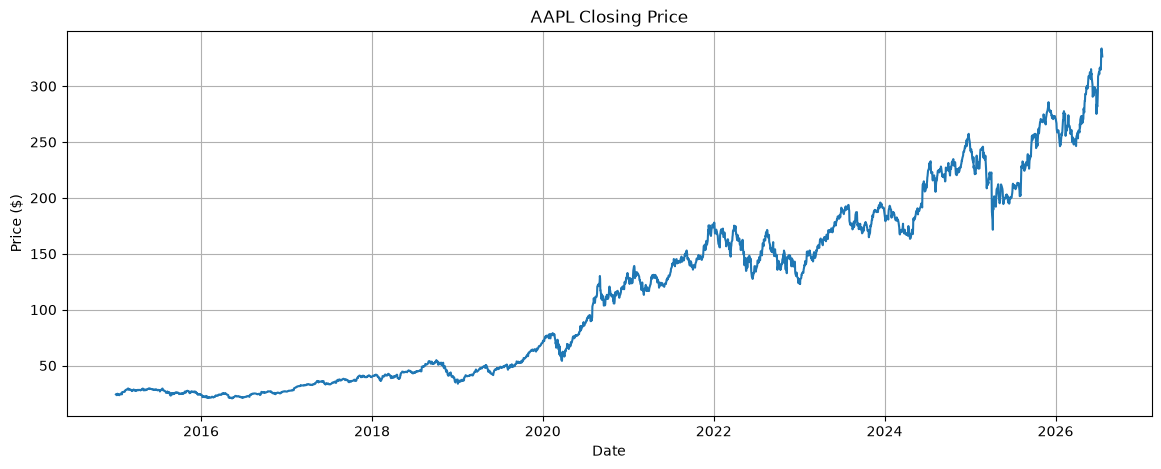

In [7]:
plt.figure(figsize=(14,5))

plt.plot(
    df.index,
    df["Close"]
)

plt.title("AAPL Closing Price")

plt.xlabel("Date")

plt.ylabel("Price ($)")

plt.grid(True)

plt.show()

In [8]:
df["Returns"] = df["Close"].pct_change()

## Daily Returns

Daily returns provide a stationary representation of price evolution and are commonly used for financial modelling.

In [10]:
df["Returns"].describe()

count    2901.000000
mean        0.001061
std         0.018105
min        -0.128647
25%        -0.007308
50%         0.000989
75%         0.010014
max         0.153289
Name: Returns, dtype: float64

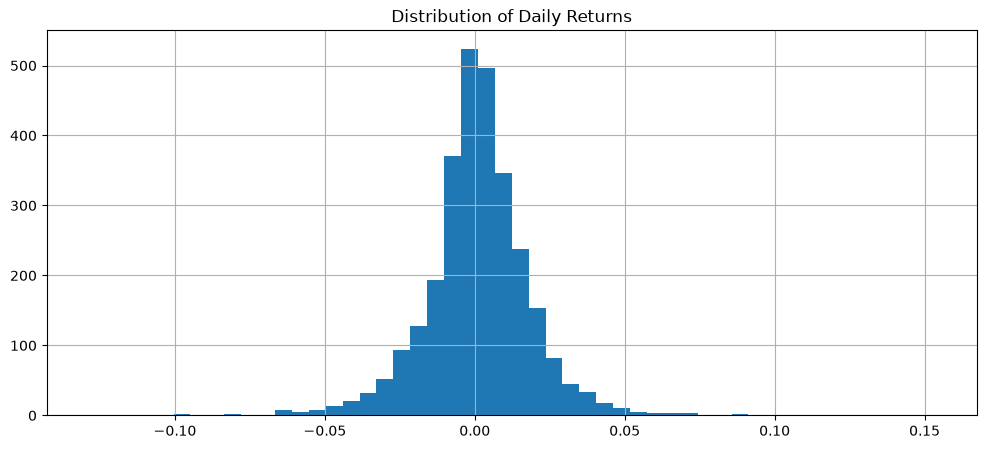

In [11]:
plt.figure(figsize=(12,5))

plt.hist(
    df["Returns"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.grid(True)

plt.show()

In [12]:
rolling_vol = (
    df["Returns"]
    .rolling(30)
    .std()
    *
    np.sqrt(252)
)

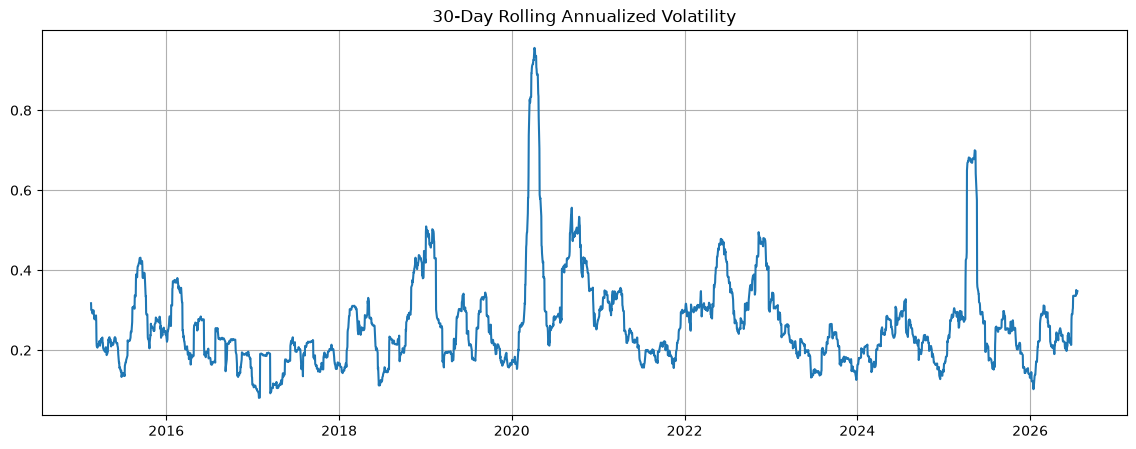

In [13]:
plt.figure(figsize=(14,5))

plt.plot(
    rolling_vol
)

plt.title("30-Day Rolling Annualized Volatility")

plt.grid(True)

plt.show()

## Key Findings

The exploratory analysis shows:

- Historical upward price trend.
- Volatility clustering over time.
- Non-normal distribution of returns.
- Suitable dataset for systematic strategy development.

The following notebook will use this dataset to generate trading signals.